We will load the solvent and solute lists used for the COSMO scripting, since they were used to build the solute + binary solvent systems activity coefficient dataset.

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi
from rdkit.Chem.rdMolDescriptors import CalcTPSA
import numpy as np

In [3]:
solute_set = pd.read_csv('C:/Users/kverg/GDI-NN/COSMO_scripting/solute_database_viable.csv')
solvent_set = pd.read_csv('C:/Users/kverg/GDI-NN/COSMO_scripting/solvent_database_viable.csv')
solvent_set

,compoundID,compoundName,charge,confAmount,molWeight,smiles,boilingPoint,meltingPoint,fileName
0,1,h2o,0.0,1,18.015,O,100.0,0.0,h2o_c0
1,2,1-octanol,0.0,2,130.229,OCCCCCCCC,195.1,-15.5,1-octanol_c0
2,45,nicotine,0.0,3,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,nicotine_c0
3,54,fenthion,0.0,3,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,fenthion_c0
4,59,"3,3'-iminodipropylamine",0.0,9,131.220,NCCCNCCCN,235.0,-14.0,"3,3'-iminodipropylamine_c0"
...,...,...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",0.0,1,338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor..."
1452,8439,isobutylsalicylate,0.0,4,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,isobutylsalicylate_c0
1453,6317,cis-3-methyl-2-hexene,0.0,1,98.187,CCCC(C)=CC,95.6,-118.5,cis-3-methyl-2-hexene_c0
1454,13169,"trans-1,4-dimethylcyclohexane",0.0,1,112.213,CC1CCC(C)CC1,119.4,-36.9,"trans-1,4-dimethylcyclohexane_c0"


We need to add a canonical smiles column and drop useless columns (fileName, confAmount, charge*)


*The variance of column charge is 0

In [4]:
## Function to create canonical smiles 
def canon(smi):
    try:
        mol=smi2mol(smi, sanitize=True)
        smi_canon=mol2smi(mol, isomericSmiles=False, canonical=True)
        return(smi_canon)
    except:
        print("ERROR")
        return(smi)
    
#### Applying function to create the column with canonical smiles.
solute_set['smiles_canon'] = [canon(smi) for smi in solute_set.smiles]
solvent_set['smiles_canon'] = [canon(smi) for smi in solvent_set.smiles]
solvent_set

,compoundID,compoundName,charge,confAmount,molWeight,smiles,boilingPoint,meltingPoint,fileName,smiles_canon
0,1,h2o,0.0,1,18.015,O,100.0,0.0,h2o_c0,O
1,2,1-octanol,0.0,2,130.229,OCCCCCCCC,195.1,-15.5,1-octanol_c0,CCCCCCCCO
2,45,nicotine,0.0,3,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,nicotine_c0,CN1CCCC1c1cccnc1
3,54,fenthion,0.0,3,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,fenthion_c0,COP(=S)(OC)Oc1ccc(SC)c(C)c1
4,59,"3,3'-iminodipropylamine",0.0,9,131.220,NCCCNCCCN,235.0,-14.0,"3,3'-iminodipropylamine_c0",NCCCNCCCN
...,...,...,...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",0.0,1,338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F
1452,8439,isobutylsalicylate,0.0,4,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,isobutylsalicylate_c0,CC(C)COC(=O)c1ccccc1O
1453,6317,cis-3-methyl-2-hexene,0.0,1,98.187,CCCC(C)=CC,95.6,-118.5,cis-3-methyl-2-hexene_c0,CC=C(C)CCC
1454,13169,"trans-1,4-dimethylcyclohexane",0.0,1,112.213,CC1CCC(C)CC1,119.4,-36.9,"trans-1,4-dimethylcyclohexane_c0",CC1CCC(C)CC1


In [5]:
solute_set = solute_set.drop(columns=['charge', 'confAmount', 'fileName'])
solvent_set = solvent_set.drop(columns=['charge', 'confAmount', 'fileName'])
solvent_set

,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon
0,1,h2o,18.015,O,100.0,0.0,O
1,2,1-octanol,130.229,OCCCCCCCC,195.1,-15.5,CCCCCCCCO
2,45,nicotine,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,CN1CCCC1c1cccnc1
3,54,fenthion,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,COP(=S)(OC)Oc1ccc(SC)c(C)c1
4,59,"3,3'-iminodipropylamine",131.220,NCCCNCCCN,235.0,-14.0,NCCCNCCCN
...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F
1452,8439,isobutylsalicylate,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,CC(C)COC(=O)c1ccccc1O
1453,6317,cis-3-methyl-2-hexene,98.187,CCCC(C)=CC,95.6,-118.5,CC=C(C)CCC
1454,13169,"trans-1,4-dimethylcyclohexane",112.213,CC1CCC(C)CC1,119.4,-36.9,CC1CCC(C)CC1


We will check for possible duplicate rows in both dataframes

In [6]:
### Calculate  the occurence of  smiles in both train and test dataset....
solute_set['occurence'] = solute_set.groupby('smiles_canon')['smiles_canon'].transform('count')
solvent_set['occurence'] = solvent_set.groupby('smiles_canon')['smiles_canon'].transform('count')
print(solute_set[solute_set['occurence']>1].shape)
print(solvent_set[solvent_set['occurence']>1].shape)
solute_set = solute_set.drop_duplicates(subset='smiles_canon', keep="last")
solvent_set = solvent_set.drop_duplicates(subset='smiles_canon', keep="last")

#Reconstruct occurence column
solute_set['occurence'] = solute_set.groupby('smiles_canon')['smiles_canon'].transform('count')
solvent_set['occurence'] = solvent_set.groupby('smiles_canon')['smiles_canon'].transform('count')
print(solute_set[solute_set['occurence']>1].shape)
print(solvent_set[solvent_set['occurence']>1].shape)
print(f'shape of solute_set is: {solute_set.shape}')
print(f'shape of solvent_set is: {solvent_set.shape}')

(2, 8)
(48, 8)
(0, 8)
(0, 8)
shape of solute_set is: (525, 8)
shape of solvent_set is: (1432, 8)


C:\Users\kverg\AppData\Local\Temp\ipykernel_25224\772939479.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solvent_set['occurence'] = solvent_set.groupby('smiles_canon')['smiles_canon'].transform('count')


We need to add a TPSA average column, since Qin and Rittig both use it for stratified sampling. These values are considered:

- polar-polar-polar (p-p-p)
- polar-polar-nonpolar (p-p-n)
- polar-nonpolar-nonpolar (p-n-n)
- nonpolar-nonpolar-nonpolar (n-n-n)

It is possible to include a stratification based on two criteria (e.g. polarity and molecular weight), but this would create a high number of categories, so we will limit the stratification only to polarity for simplicity's sake.

The polar/nonpolar threshold will be set at 20 Å^2.

In [7]:
def add_molecular_descriptor_to_dataframe(df, descriptor, rdkit_fun):
    descriptor_vect = []
    for smiles in df['smiles_canon']:
        try:
            descriptor_elem = rdkit_fun(Chem.MolFromSmiles(smiles))
        except:
            descriptor_elem = None
        descriptor_vect.append(descriptor_elem)
    df[descriptor] = descriptor_vect

add_molecular_descriptor_to_dataframe(solute_set, 'TPSA', CalcTPSA)
add_molecular_descriptor_to_dataframe(solvent_set, 'TPSA', CalcTPSA)
solvent_set


C:\Users\kverg\AppData\Local\Temp\ipykernel_25224\2413319322.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[descriptor] = descriptor_vect


,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon,occurence,TPSA
0,1,h2o,18.015,O,100.0,0.0,O,1,31.50
1,2,1-octanol,130.229,OCCCCCCCC,195.1,-15.5,CCCCCCCCO,1,20.23
2,45,nicotine,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,CN1CCCC1c1cccnc1,1,16.13
3,54,fenthion,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,COP(=S)(OC)Oc1ccc(SC)c(C)c1,1,27.69
4,59,"3,3'-iminodipropylamine",131.220,NCCCNCCCN,235.0,-14.0,NCCCNCCCN,1,64.07
...,...,...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,1,0.00
1452,8439,isobutylsalicylate,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,CC(C)COC(=O)c1ccccc1O,1,46.53
1453,6317,cis-3-methyl-2-hexene,98.187,CCCC(C)=CC,95.6,-118.5,CC=C(C)CCC,1,0.00
1454,13169,"trans-1,4-dimethylcyclohexane",112.213,CC1CCC(C)CC1,119.4,-36.9,CC1CCC(C)CC1,1,0.00


[[<Axes: title={'center': 'TPSA'}>]]
[[<Axes: title={'center': 'TPSA'}>]]


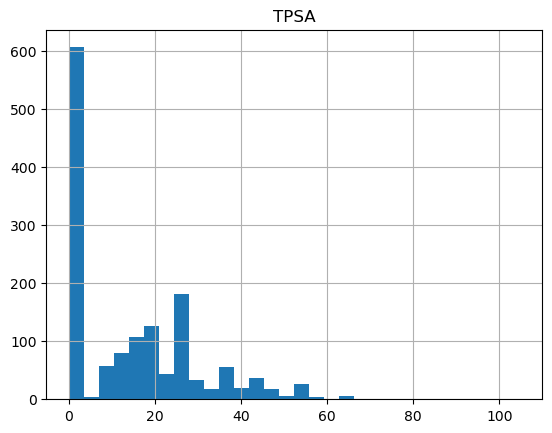

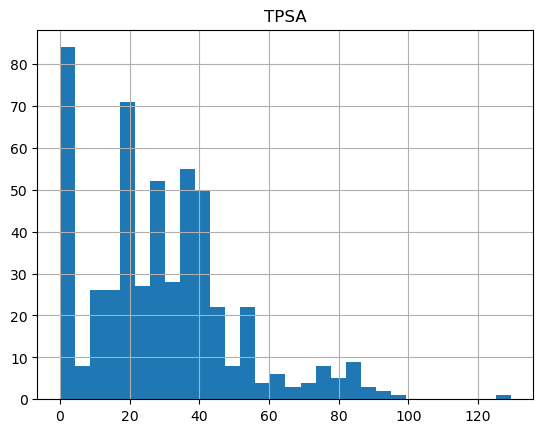

In [8]:
print(solvent_set.hist(column=['TPSA'], bins=30))
print(solute_set.hist(column=['TPSA'], bins=30))

In [9]:
solute_set = solute_set.drop(columns=['occurence'])
solvent_set = solvent_set.drop(columns=['occurence'])
solvent_set

,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon,TPSA
0,1,h2o,18.015,O,100.0,0.0,O,31.50
1,2,1-octanol,130.229,OCCCCCCCC,195.1,-15.5,CCCCCCCCO,20.23
2,45,nicotine,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,CN1CCCC1c1cccnc1,16.13
3,54,fenthion,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,COP(=S)(OC)Oc1ccc(SC)c(C)c1,27.69
4,59,"3,3'-iminodipropylamine",131.220,NCCCNCCCN,235.0,-14.0,NCCCNCCCN,64.07
...,...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,0.00
1452,8439,isobutylsalicylate,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,CC(C)COC(=O)c1ccccc1O,46.53
1453,6317,cis-3-methyl-2-hexene,98.187,CCCC(C)=CC,95.6,-118.5,CC=C(C)CCC,0.00
1454,13169,"trans-1,4-dimethylcyclohexane",112.213,CC1CCC(C)CC1,119.4,-36.9,CC1CCC(C)CC1,0.00


In [10]:
solute_set

,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon,TPSA
0,24,1h-benzimidazole,118.137,c1cc2nc[nH]c2cc1,360.0,170.5,c1ccc2[nH]cnc2c1,28.68
1,33,4-methoxyacetanilide,165.190,COc1ccc(cc1)NC(C)=O,335.0,131.0,COc1ccc(NC(C)=O)cc1,38.33
2,43,"dibenz(a,h)anthracene",278.348,c(ccc1c2cc3c4)cc1ccc2cc3c1ccccc1c4,524.0,269.5,c1ccc2c(c1)ccc1cc3c(ccc4ccccc43)cc12,0.00
3,52,benzamide,121.137,O=C(c1ccccc1)N,290.0,129.1,NC(=O)c1ccccc1,43.09
4,69,benz(a)anthracene,228.289,c(ccc1cc2c3ccccc3c3)cc1cc2c3,437.6,84.0,c1ccc2cc3c(ccc4ccccc43)cc2c1,0.00
...,...,...,...,...,...,...,...,...
521,7836,"3,5-dimethyl-4-chloropyrazole",130.576,Cc1n[nH]c(C)c1Cl,221.0,117.5,Cc1n[nH]c(C)c1Cl,28.68
522,7850,orivone,168.277,CCC(C)(C)C1CCC(CC1)=O,124.0,96.0,CCC(C)(C)C1CCC(=O)CC1,17.07
523,8078,carnaline,182.174,COC(=O)c(ccc1O)cc1OC,286.0,64.0,COC(=O)c1ccc(O)c(OC)c1,55.76
524,8141,ethyl-pentafluoropropionate,192.085,CCOC(C(F)(F)C(F)(F)F)=O,75.0,75.5,CCOC(=O)C(F)(F)C(F)(F)F,26.30


We proceed to load the training set CSV and include canonic smiles and polarity class.

In [11]:
systems_set = pd.read_csv("C:/Users/kverg/GDI-NN/COSMO_scripting/solute_BinarySolvent_infinite_dilution_activity_coefficients_postprocessed.csv")
systems_set

,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2
0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9
1,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7
2,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5
3,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3
4,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1
...,...,...,...,...,...,...,...,...
198740,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9
198741,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7
198742,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5
198743,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3


In [12]:
def get_cell_value(colname, row):
    try:
        value = row[colname].values[0]
    except:
        value = None
    return value

solv1_id = []
solv2_id = []
solute_id = []
smiles_canon_solv1 = []
smiles_canon_solv2 = []
smiles_canon_solute = []
polarity_solv1 = []
polarity_solv2 = []
polarity_solute = []
for i in range(systems_set.shape[0]):
    row = systems_set.iloc[i]
    solute_name = row['solute']
    solvent1_name = row['solvent_1']
    solvent2_name = row['solvent_2']
    
    solute_row = solute_set[solute_set['compoundName']==solute_name]
    solvent1_row = solvent_set[solvent_set['compoundName']==solvent1_name]
    solvent2_row = solvent_set[solvent_set['compoundName']==solvent2_name]
    
    solv1_id.append(get_cell_value('compoundID', solvent1_row))
    solv2_id.append(get_cell_value('compoundID', solvent2_row))
    solute_id.append(get_cell_value('compoundID', solute_row))
    smiles_canon_solv1.append(get_cell_value('smiles_canon', solvent1_row))
    smiles_canon_solv2.append(get_cell_value('smiles_canon', solvent2_row))
    smiles_canon_solute.append(get_cell_value('smiles_canon', solute_row))
    polarity_solv1.append(get_cell_value('TPSA', solvent1_row))
    polarity_solv2.append(get_cell_value('TPSA', solvent2_row))
    polarity_solute.append(get_cell_value('TPSA', solute_row))

    if i % 10000 ==0:
        print(i)



0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000


In [13]:
systems_set['solv1_id'] = solv1_id
systems_set['solv2_id'] = solv2_id
systems_set['solute_id'] = solute_id
systems_set['smiles_canon_solv1'] = smiles_canon_solv1
systems_set['smiles_canon_solv2'] = smiles_canon_solv2
systems_set['smiles_canon_solute'] = smiles_canon_solute
systems_set['polarity_solv1'] = polarity_solv1
systems_set['polarity_solv2'] = polarity_solv2
systems_set['polarity_solute'] = polarity_solute
systems_set

,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,solv1_id,solv2_id,solute_id,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_solv1,polarity_solv2,polarity_solute
0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
1,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
2,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
3,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
4,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198741,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198742,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198743,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79


In [14]:
systems_set = systems_set.dropna()
systems_set

,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,solv1_id,solv2_id,solute_id,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_solv1,polarity_solv2,polarity_solute
0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
1,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
2,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
3,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
4,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,59.0,883.0,2857.0,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198741,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198742,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198743,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,1458.0,2855.0,621.0,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79


In [15]:
systems_set = systems_set[['solv1_id', 'solv2_id', 'solute_id',
                           'solvent_1', 'solvent_2', 'solute',
                           'ln(gamma)_solvent_1', 'ln(gamma)_solvent_2', 'ln(gamma)_solute', 'x1', 'x2',
                            'smiles_canon_solv1', 'smiles_canon_solv2', 'smiles_canon_solute',
                            'polarity_solv1', 'polarity_solv2', 'polarity_solute']]
systems_set

,solv1_id,solv2_id,solute_id,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_solv1,polarity_solv2,polarity_solute
0,59.0,883.0,2857.0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
1,59.0,883.0,2857.0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
2,59.0,883.0,2857.0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
3,59.0,883.0,2857.0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
4,59.0,883.0,2857.0,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,1458.0,2855.0,621.0,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198741,1458.0,2855.0,621.0,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198742,1458.0,2855.0,621.0,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198743,1458.0,2855.0,621.0,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79


In [16]:
systems_set['solv1_id'] = systems_set['solv1_id'].astype(int)
systems_set['solv2_id'] = systems_set['solv2_id'].astype(int)
systems_set['solute_id'] = systems_set['solute_id'].astype(int)
systems_set

,solv1_id,solv2_id,solute_id,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_solv1,polarity_solv2,polarity_solute
0,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
1,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
2,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
3,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
4,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,64.07,0.0,20.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198741,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198742,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79
198743,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,26.30,0.0,15.79


The TPSA values must be converted to polar or nonpolar according to a threshold of 20.

In [17]:
systems_set['polarity_solv1'] = np.where(systems_set['polarity_solv1'] >= 20, 'p', 'n')
systems_set['polarity_solv2'] = np.where(systems_set['polarity_solv2'] >= 20, 'p', 'n')
systems_set['polarity_solute'] = np.where(systems_set['polarity_solute'] >= 20, 'p', 'n')
systems_set

,solv1_id,solv2_id,solute_id,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_solv1,polarity_solv2,polarity_solute
0,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,p,n,p
1,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,p,n,p
2,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,p,n,p
3,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,p,n,p
4,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,p,n,p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,p,n,n
198741,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,p,n,n
198742,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,p,n,n
198743,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,p,n,n


In [18]:
polarity_class = []
for i in range(systems_set.shape[0]):
    row = systems_set.iloc[i]
    polarity = row['polarity_solv1'] + row['polarity_solv2'] + row['polarity_solute']
    count_p = polarity.count('p')
    if count_p == 3:
        polarity_ordered = 'ppp'
    elif count_p == 2:
        polarity_ordered = 'npp'
    elif count_p == 1:
        polarity_ordered = 'nnp'
    elif count_p == 0:
        polarity_ordered = 'nnn'
    polarity_class.append(polarity_ordered)
systems_set['polarity_class'] = polarity_class
systems_set = systems_set.drop(columns=['polarity_solv1', 'polarity_solv2', 'polarity_solute'])
systems_set

,solv1_id,solv2_id,solute_id,solvent_1,solvent_2,solute,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,x1,x2,smiles_canon_solv1,smiles_canon_solv2,smiles_canon_solute,polarity_class
0,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",1.427327,0.032938,-7.163831,0.1,0.9,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,npp
1,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.687263,0.207344,-8.368745,0.3,0.7,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,npp
2,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.297736,0.458563,-8.833765,0.5,0.5,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,npp
3,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.094019,0.754320,-9.073319,0.7,0.3,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,npp
4,59,883,2857,"3,3'-iminodipropylamine","1-methyl-4-(1-methylethyl)-1,4-cyclohexadiene","2,3-dichlorophenol",0.009737,1.075151,-9.202448,0.9,0.1,NCCCNCCCN,CC1=CCC(C(C)C)=CC1,Oc1cccc(Cl)c1Cl,npp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198740,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.072008,0.001629,0.090061,0.1,0.9,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,nnp
198741,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.032056,0.011175,-0.139866,0.3,0.7,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,nnp
198742,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.012166,0.024042,-0.304215,0.5,0.5,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,nnp
198743,1458,2855,621,aceticaciddecylester,"1,6-dimethylnaphthalene","2,3-dimethyl-1h-indole",0.003283,0.036963,-0.431358,0.7,0.3,CCCCCCCCCCOC(C)=O,Cc1ccc2c(C)cccc2c1,Cc1[nH]c2ccccc2c1C,nnp


Save to CSV

In [19]:
systems_set.to_csv('C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/systems_train.csv', index=False)

In [20]:
solute_set

,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon,TPSA
0,24,1h-benzimidazole,118.137,c1cc2nc[nH]c2cc1,360.0,170.5,c1ccc2[nH]cnc2c1,28.68
1,33,4-methoxyacetanilide,165.190,COc1ccc(cc1)NC(C)=O,335.0,131.0,COc1ccc(NC(C)=O)cc1,38.33
2,43,"dibenz(a,h)anthracene",278.348,c(ccc1c2cc3c4)cc1ccc2cc3c1ccccc1c4,524.0,269.5,c1ccc2c(c1)ccc1cc3c(ccc4ccccc43)cc12,0.00
3,52,benzamide,121.137,O=C(c1ccccc1)N,290.0,129.1,NC(=O)c1ccccc1,43.09
4,69,benz(a)anthracene,228.289,c(ccc1cc2c3ccccc3c3)cc1cc2c3,437.6,84.0,c1ccc2cc3c(ccc4ccccc43)cc2c1,0.00
...,...,...,...,...,...,...,...,...
521,7836,"3,5-dimethyl-4-chloropyrazole",130.576,Cc1n[nH]c(C)c1Cl,221.0,117.5,Cc1n[nH]c(C)c1Cl,28.68
522,7850,orivone,168.277,CCC(C)(C)C1CCC(CC1)=O,124.0,96.0,CCC(C)(C)C1CCC(=O)CC1,17.07
523,8078,carnaline,182.174,COC(=O)c(ccc1O)cc1OC,286.0,64.0,COC(=O)c1ccc(O)c(OC)c1,55.76
524,8141,ethyl-pentafluoropropionate,192.085,CCOC(C(F)(F)C(F)(F)F)=O,75.0,75.5,CCOC(=O)C(F)(F)C(F)(F)F,26.30


In [21]:
solvent_set

,compoundID,compoundName,molWeight,smiles,boilingPoint,meltingPoint,smiles_canon,TPSA
0,1,h2o,18.015,O,100.0,0.0,O,31.50
1,2,1-octanol,130.229,OCCCCCCCC,195.1,-15.5,CCCCCCCCO,20.23
2,45,nicotine,162.232,CN1CCCC1c1cccnc1,247.0,-79.0,CN1CCCC1c1cccnc1,16.13
3,54,fenthion,278.330,CSc1ccc(OP(OC)(OC)=S)cc1C,87.0,7.5,COP(=S)(OC)Oc1ccc(SC)c(C)c1,27.69
4,59,"3,3'-iminodipropylamine",131.220,NCCCNCCCN,235.0,-14.0,NCCCNCCCN,64.07
...,...,...,...,...,...,...,...,...
1451,8438,"1,1,1,2,2,3,4,4,5,5,5-undecafluoro-3-(trifluor...",338.042,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,58.4,-115.0,FC(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)C(F)(F)F,0.00
1452,8439,isobutylsalicylate,194.228,CC(C)COC(=O)c1ccccc1O,261.0,5.9,CC(C)COC(=O)c1ccccc1O,46.53
1453,6317,cis-3-methyl-2-hexene,98.187,CCCC(C)=CC,95.6,-118.5,CC=C(C)CCC,0.00
1454,13169,"trans-1,4-dimethylcyclohexane",112.213,CC1CCC(C)CC1,119.4,-36.9,CC1CCC(C)CC1,0.00


In [22]:
solvent_set.to_csv("C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solvent_list_solub.csv", index=False)
solute_set.to_csv("C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solute_list_solub.csv", index=False)

In [25]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi
from rdkit.Chem.rdMolDescriptors import CalcTPSA
import numpy as np

systems_set = pd.read_csv("C:/Users/kverg/GDI-NN/COSMO_scripting/test_systems_old_old_postprocessed.csv")
solvent_set = pd.read_csv("C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solvent_list_solub.csv")
solute_set = pd.read_csv("C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/solute_list_solub.csv")

def get_cell_value(colname, row):
    try:
        value = row[colname].values[0]
    except:
        value = None
    return value

solv1_id = []
solv2_id = []
solute_id = []
smiles_canon_solv1 = []
smiles_canon_solv2 = []
smiles_canon_solute = []
polarity_solv1 = []
polarity_solv2 = []
polarity_solute = []
for i in range(systems_set.shape[0]):
    row = systems_set.iloc[i]
    solute_name = row['solute']
    solvent1_name = row['solvent_1']
    solvent2_name = row['solvent_2']
    
    solute_row = solute_set[solute_set['compoundName']==solute_name]
    solvent1_row = solvent_set[solvent_set['compoundName']==solvent1_name]
    solvent2_row = solvent_set[solvent_set['compoundName']==solvent2_name]
    
    solv1_id.append(get_cell_value('compoundID', solvent1_row))
    solv2_id.append(get_cell_value('compoundID', solvent2_row))
    solute_id.append(get_cell_value('compoundID', solute_row))
    smiles_canon_solv1.append(get_cell_value('smiles_canon', solvent1_row))
    smiles_canon_solv2.append(get_cell_value('smiles_canon', solvent2_row))
    smiles_canon_solute.append(get_cell_value('smiles_canon', solute_row))
    polarity_solv1.append(get_cell_value('TPSA', solvent1_row))
    polarity_solv2.append(get_cell_value('TPSA', solvent2_row))
    polarity_solute.append(get_cell_value('TPSA', solute_row))

    if i % 1000 ==0:
        print(i)

systems_set['solv1_id'] = solv1_id
systems_set['solv2_id'] = solv2_id
systems_set['solute_id'] = solute_id
systems_set['smiles_canon_solv1'] = smiles_canon_solv1
systems_set['smiles_canon_solv2'] = smiles_canon_solv2
systems_set['smiles_canon_solute'] = smiles_canon_solute
systems_set['polarity_solv1'] = polarity_solv1
systems_set['polarity_solv2'] = polarity_solv2
systems_set['polarity_solute'] = polarity_solute
systems_set

systems_set = systems_set.dropna()

systems_set = systems_set[['solv1_id', 'solv2_id', 'solute_id',
                           'solvent_1', 'solvent_2', 'solute',
                           'ln(gamma)_solvent_1', 'ln(gamma)_solvent_2', 'ln(gamma)_solute', 'x1', 'x2',
                            'smiles_canon_solv1', 'smiles_canon_solv2', 'smiles_canon_solute',
                            'polarity_solv1', 'polarity_solv2', 'polarity_solute']]

systems_set['solv1_id'] = systems_set['solv1_id'].astype(int)
systems_set['solv2_id'] = systems_set['solv2_id'].astype(int)
systems_set['solute_id'] = systems_set['solute_id'].astype(int)

systems_set['polarity_solv1'] = np.where(systems_set['polarity_solv1'] >= 20, 'p', 'n')
systems_set['polarity_solv2'] = np.where(systems_set['polarity_solv2'] >= 20, 'p', 'n')
systems_set['polarity_solute'] = np.where(systems_set['polarity_solute'] >= 20, 'p', 'n')

polarity_class = []
for i in range(systems_set.shape[0]):
    row = systems_set.iloc[i]
    polarity = row['polarity_solv1'] + row['polarity_solv2'] + row['polarity_solute']
    count_p = polarity.count('p')
    if count_p == 3:
        polarity_ordered = 'ppp'
    elif count_p == 2:
        polarity_ordered = 'npp'
    elif count_p == 1:
        polarity_ordered = 'nnp'
    elif count_p == 0:
        polarity_ordered = 'nnn'
    polarity_class.append(polarity_ordered)
systems_set['polarity_class'] = polarity_class
systems_set = systems_set.drop(columns=['polarity_solv1', 'polarity_solv2', 'polarity_solute'])

systems_set.to_csv('C:/Users/kverg/GDI-NN/data/infinite_dilution_activity_ternary/systems_test_old_old.csv', index=False)

0
1000
2000
3000
4000
